# **A**- Chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("/content/drive/MyDrive/validation-reseau-trafic.csv", sep=";")


In [3]:
# Pour voir les 5 premières lignes de notre fichier
df.head()

,CODE_STIF_TRNS,CODE_STIF_RES,CODE_STIF_LIGNE,LIBELLE_LIGNE,ID_GROUPOFLIGNE,CAT_JOUR,TRNC_HORR_60,Pourcentage_validations
0,100,594,585,585 (Valouette V7),A01239,SAHV,8H-9H,25.00
1,100,987,751,N24,A01243,DIJFP,13H-14H,0.15
2,100,987,751,N24,A01243,DIJFP,20H-21H,0.41
3,100,987,751,N24,A01243,DIJFP,2H-3H,15.96
4,100,987,751,N24,A01243,DIJFP,3H-4H,11.24


# **B**- Nettoyage

In [4]:
# Pour voir les informations sur les colonnes
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110782 entries, 0 to 110781
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   CODE_STIF_TRNS           110782 non-null  int64  
 1   CODE_STIF_RES            110782 non-null  object 
 2   CODE_STIF_LIGNE          110782 non-null  object 
 3   LIBELLE_LIGNE            110782 non-null  object 
 4   ID_GROUPOFLIGNE          110782 non-null  object 
 5   CAT_JOUR                 110782 non-null  object 
 6   TRNC_HORR_60             110782 non-null  object 
 7   Pourcentage_validations  110782 non-null  float64
dtypes: float64(1), int64(1), object(6)
memory usage: 6.8+ MB


# **DESCRIPTIONS DES VARIABLES**

CODE_STIF_TRNS : Code identifiant le type de transport (mode de transport du réseau de surface : bus, tram, etc.).

CODE_STIF_RES : Code identifiant le réseau d’exploitation auquel appartient la ligne (opérateur ou sous-réseau).

CODE_STIF_LIGNE : Identifiant technique unique de la ligne dans la base de données.

LIBELLE_LIGNE : Nom ou libellé commercial de la ligne (ex : “585 (Valouette V7)”, “N24”).

ID_GROUPOFLIGNE : Identifiant du groupe de lignes auquel appartient la ligne (permet de regrouper plusieurs lignes similaires).

CAT_JOUR : Catégorie du jour correspondant au type de journée (ex : jour de semaine, samedi, dimanche, vacances scolaires).

TRNC_HORR_60 : Tranche horaire d’une durée de 60 minutes (ex : 8H-9H, 13H-14H, 20H-21H).

Pourcentage_validations : Pourcentage des validations (titres de transport validés) réalisées sur la ligne durant la tranche horaire considérée ; représente la répartition de l’affluence journalière par heure

In [5]:
# Permet d'afficher les statistiques descriptives
df.describe()

,CODE_STIF_TRNS,Pourcentage_validations
count,110782.000000,110782.000000
mean,388.912341,7.086875
std,196.266728,8.840349
min,3.000000,0.000000
25%,100.000000,2.432500
50%,510.000000,5.560000
75%,525.000000,8.140000
max,900.000000,100.000000


# Définition des éléments dans df.describe()

**- count**

CODE_STIF_TRNS : 110 782
Pourcentage_validations : 110 782

Le nombre d’entrées non nulles dans chaque colonne.
Ici, les deux variables contiennent 110 782 observations, ce qui signifie qu’il n’y a pas de valeurs manquantes dans ces colonnes.

 **- mean (moyenne)**

CODE_STIF_TRNS : 388.91
Il s’agit de la moyenne des codes identifiant les types de transport.
 Cette moyenne n’a pas d’interprétation métier directe, car il s’agit d’un identifiant numérique.

Pourcentage_validations : 7.09
En moyenne, une tranche horaire représente 7,09 % des validations journalières d’une ligne.

**- std (écart type)**

CODE_STIF_TRNS : 196.27
Indique la dispersion des codes de transport autour de la moyenne.
Encore une fois, cette mesure est peu interprétable car la variable est un identifiant.

Pourcentage_validations : 8.84
Montre que la répartition horaire des validations est assez dispersée.
Certaines tranches horaires concentrent beaucoup plus de validations que d’autres.

**- min (valeur minimale)**

CODE_STIF_TRNS : 3
Le plus petit code transport observé.

Pourcentage_validations : 0
Certaines tranches horaires ne représentent aucune validation (probablement heures très creuses ou lignes spécifiques).

**- 25% (premier quartile, Q1)**

CODE_STIF_TRNS : 100
25 % des codes sont inférieurs ou égaux à 100.

Pourcentage_validations : 2.43
25 % des tranches horaires représentent moins de 2,43 % des validations journalières.
Cela correspond aux périodes creuses.

**- 50% (médiane, Q2)**

CODE_STIF_TRNS : 510
La moitié des codes sont inférieurs ou égaux à 510.

Pourcentage_validations : 5.56
La médiane indique que 50 % des tranches horaires représentent moins de 5,56 % des validations.
Cela signifie que la majorité des heures ont une affluence modérée.

 **- 75% (troisième quartile, Q3)**

CODE_STIF_TRNS : 525
75 % des codes sont inférieurs ou égaux à 525.

Pourcentage_validations : 8.14
75 % des tranches horaires représentent moins de 8,14 % des validations.
Les heures dépassant cette valeur correspondent aux pics d’affluence.

**- max (valeur maximale)**

CODE_STIF_TRNS : 900
Code transport le plus élevé observé.

Pourcentage_validations : 100
Une tranche horaire peut représenter 100 % des validations journalières (cas particulier : ligne avec activité concentrée sur une seule heure ou anomalie à vérifier).

Interprétation globale importante

# La variable Pourcentage_validations montre :

Une médiane (5,56 %) inférieure à la moyenne (7,09 %)
→ Indice d’une distribution asymétrique à droite
→ Certaines heures concentrent une forte proportion de validations (pics matin/soir)

In [6]:
# Vérifie les valeures manquantes dans le colonnes
print(df.isnull().sum())

CODE_STIF_TRNS             0
CODE_STIF_RES              0
CODE_STIF_LIGNE            0
LIBELLE_LIGNE              0
ID_GROUPOFLIGNE            0
CAT_JOUR                   0
TRNC_HORR_60               0
Pourcentage_validations    0
dtype: int64


# Feature Engineering
(transformations des données brutes en variables exploitables et informatives pour le modèle.)

1. Transformer la tranche

*   Élément de liste
*   Élément de liste

**horaire**

In [7]:
df_copy = df.copy()

In [8]:
df_copy["Heure"] = (
    df["TRNC_HORR_60"]
    .str.split("H").str[0]
    .replace("ND", None)
    .astype(float)
)

In [9]:
# Extraction de l'heure et conversion en numérique
df_copy['Heure_Debut'] = df_copy['TRNC_HORR_60'].str.extract(r'^(\d+)')
df_copy['Heure_Debut'] = pd.to_numeric(df_copy['Heure_Debut'], errors='coerce').astype('Int64')
df_copy = df_copy.dropna(subset=["Heure_Debut"])
df_copy["Heure_Debut"] = df_copy["Heure_Debut"].astype(int)

# ENSUITE on fait le One-Hot Encoding sur df_copy !
df_copy = pd.get_dummies(df_copy, columns=["CAT_JOUR"], drop_first=True)

In [10]:
# On transforme le type de transport en colonnes de 0 et 1
df_copy = pd.get_dummies(df_copy, columns=["CODE_STIF_TRNS"], drop_first=True)

In [11]:
df_copy["TRNC_HORR_60"].unique()

array(['8H-9H', '13H-14H', '20H-21H', '2H-3H', '3H-4H', '0H-1H', '6H-7H',
       '1H-2H', '19H-20H', '4H-5H', '16H-17H', '17H-18H', '23H-0H',
       '7H-8H', '11H-12H', '5H-6H', '14H-15H', '18H-19H', '10H-11H',
       '12H-13H', '22H-23H', '9H-10H', '15H-16H', '21H-22H'], dtype=object)

In [12]:
# 1. On extrait les chiffres sous forme de texte d'abord
df_copy['Heure_Debut'] = df_copy['TRNC_HORR_60'].str.extract(r'^(\d+)')

# 2. On convertit en numérique proprement.
# L'astuce : utiliser 'Int64' (avec un I majuscule). C'est un type spécifique à Pandas
# qui permet d'avoir des nombres entiers ET des NaN dans la même colonne sans planter !
df_copy['Heure_Debut'] = pd.to_numeric(df_copy['Heure_Debut'], errors='coerce').astype('Int64')

# 3. Menons l'enquête : affichons les valeurs d'origine qui n'ont pas de chiffre
valeurs_problematiques = df_copy[df_copy['Heure_Debut'].isna()]['TRNC_HORR_60'].unique()
print("Voici les textes bizarres qui ont causé l'erreur :", valeurs_problematiques)

# 4. On vérifie le résultat final
print("\nAperçu des heures extraites :")
print(df_copy[['TRNC_HORR_60', 'Heure_Debut']].head())

Voici les textes bizarres qui ont causé l'erreur : []

Aperçu des heures extraites :
  TRNC_HORR_60  Heure_Debut
0        8H-9H            8
1      13H-14H           13
2      20H-21H           20
3        2H-3H            2
4        3H-4H            3


In [13]:
# On utilise bien le nom exact de la colonne : "Heure_Debut"
df_copy = df_copy.dropna(subset=["Heure_Debut"])

# Petit bonus : on affiche la taille du dataset pour voir combien de lignes il reste
print("Dimensions du dataset après nettoyage :", df_copy.shape)

Dimensions du dataset après nettoyage : (110780, 66)


In [14]:
df_copy["Heure_Debut"] = df_copy["Heure_Debut"].astype(int)

# On vérifie le type de la colonne pour s'assurer que c'est bien un entier (int)
print(df_copy["Heure_Debut"].dtype)

int64


2. Encoder les variables catégorielles

In [15]:
print(df_copy.columns)

Index(['CODE_STIF_RES', 'CODE_STIF_LIGNE', 'LIBELLE_LIGNE', 'ID_GROUPOFLIGNE',
       'TRNC_HORR_60', 'Pourcentage_validations', 'Heure', 'Heure_Debut',
       'CAT_JOUR_JOHV', 'CAT_JOUR_JOVS', 'CAT_JOUR_SAHV', 'CAT_JOUR_SAVS',
       'CODE_STIF_TRNS_14', 'CODE_STIF_TRNS_20', 'CODE_STIF_TRNS_39',
       'CODE_STIF_TRNS_51', 'CODE_STIF_TRNS_97', 'CODE_STIF_TRNS_100',
       'CODE_STIF_TRNS_101', 'CODE_STIF_TRNS_111', 'CODE_STIF_TRNS_191',
       'CODE_STIF_TRNS_233', 'CODE_STIF_TRNS_293', 'CODE_STIF_TRNS_314',
       'CODE_STIF_TRNS_333', 'CODE_STIF_TRNS_501', 'CODE_STIF_TRNS_502',
       'CODE_STIF_TRNS_503', 'CODE_STIF_TRNS_504', 'CODE_STIF_TRNS_505',
       'CODE_STIF_TRNS_506', 'CODE_STIF_TRNS_507', 'CODE_STIF_TRNS_508',
       'CODE_STIF_TRNS_509', 'CODE_STIF_TRNS_510', 'CODE_STIF_TRNS_511',
       'CODE_STIF_TRNS_512', 'CODE_STIF_TRNS_513', 'CODE_STIF_TRNS_514',
       'CODE_STIF_TRNS_515', 'CODE_STIF_TRNS_516', 'CODE_STIF_TRNS_517',
       'CODE_STIF_TRNS_518', 'CODE_STIF_TRNS_51

In [16]:
df_copy.columns = df_copy.columns.str.strip()

In [17]:
print(df_copy.columns)

Index(['CODE_STIF_RES', 'CODE_STIF_LIGNE', 'LIBELLE_LIGNE', 'ID_GROUPOFLIGNE',
       'TRNC_HORR_60', 'Pourcentage_validations', 'Heure', 'Heure_Debut',
       'CAT_JOUR_JOHV', 'CAT_JOUR_JOVS', 'CAT_JOUR_SAHV', 'CAT_JOUR_SAVS',
       'CODE_STIF_TRNS_14', 'CODE_STIF_TRNS_20', 'CODE_STIF_TRNS_39',
       'CODE_STIF_TRNS_51', 'CODE_STIF_TRNS_97', 'CODE_STIF_TRNS_100',
       'CODE_STIF_TRNS_101', 'CODE_STIF_TRNS_111', 'CODE_STIF_TRNS_191',
       'CODE_STIF_TRNS_233', 'CODE_STIF_TRNS_293', 'CODE_STIF_TRNS_314',
       'CODE_STIF_TRNS_333', 'CODE_STIF_TRNS_501', 'CODE_STIF_TRNS_502',
       'CODE_STIF_TRNS_503', 'CODE_STIF_TRNS_504', 'CODE_STIF_TRNS_505',
       'CODE_STIF_TRNS_506', 'CODE_STIF_TRNS_507', 'CODE_STIF_TRNS_508',
       'CODE_STIF_TRNS_509', 'CODE_STIF_TRNS_510', 'CODE_STIF_TRNS_511',
       'CODE_STIF_TRNS_512', 'CODE_STIF_TRNS_513', 'CODE_STIF_TRNS_514',
       'CODE_STIF_TRNS_515', 'CODE_STIF_TRNS_516', 'CODE_STIF_TRNS_517',
       'CODE_STIF_TRNS_518', 'CODE_STIF_TRNS_51

Ici on constate que nous n'avons aucune ligne manquante dans ce jeu de donnee

In [18]:
# Vérifie les lignes dupliquer dans le jeu de donnee
duplicate_rows = df_copy.duplicated()

# Compte le nombre de ligne dupliquer
num_duplicate_rows = duplicate_rows.sum()

# Affiche le nombre de ligne dupliquer
print("Nombres de ligne dupliquer:", num_duplicate_rows)

# Affiche la ligne dupliquer
duplicate_rows_index = df_copy[duplicate_rows].index
print("Index de la ligne dupliquer:", duplicate_rows_index)

Nombres de ligne dupliquer: 0
Index de la ligne dupliquer: Index([], dtype='int64')


Ici on constate que nous navons aucunes ligne dupliquer ce qui est bien

In [19]:
df_copy.value_counts()

CODE_STIF_RES  CODE_STIF_LIGNE  LIBELLE_LIGNE                                              ID_GROUPOFLIGNE  TRNC_HORR_60  Pourcentage_validations  Heure  Heure_Debut  CAT_JOUR_JOHV  CAT_JOUR_JOVS  CAT_JOUR_SAHV  CAT_JOUR_SAVS  CODE_STIF_TRNS_14  CODE_STIF_TRNS_20  CODE_STIF_TRNS_39  CODE_STIF_TRNS_51  CODE_STIF_TRNS_97  CODE_STIF_TRNS_100  CODE_STIF_TRNS_101  CODE_STIF_TRNS_111  CODE_STIF_TRNS_191  CODE_STIF_TRNS_233  CODE_STIF_TRNS_293  CODE_STIF_TRNS_314  CODE_STIF_TRNS_333  CODE_STIF_TRNS_501  CODE_STIF_TRNS_502  CODE_STIF_TRNS_503  CODE_STIF_TRNS_504  CODE_STIF_TRNS_505  CODE_STIF_TRNS_506  CODE_STIF_TRNS_507  CODE_STIF_TRNS_508  CODE_STIF_TRNS_509  CODE_STIF_TRNS_510  CODE_STIF_TRNS_511  CODE_STIF_TRNS_512  CODE_STIF_TRNS_513  CODE_STIF_TRNS_514  CODE_STIF_TRNS_515  CODE_STIF_TRNS_516  CODE_STIF_TRNS_517  CODE_STIF_TRNS_518  CODE_STIF_TRNS_519  CODE_STIF_TRNS_520  CODE_STIF_TRNS_521  CODE_STIF_TRNS_522  CODE_STIF_TRNS_523  CODE_STIF_TRNS_524  CODE_STIF_TRNS_525  CODE_STIF_TRNS_526  CODE_STIF_TRNS_527  CODE_STIF_TRNS_528  CODE_STIF_TRNS_529  CODE_STIF_TRNS_530  CODE_STIF_TRNS_531  CODE_STIF_TRNS_532  CODE_STIF_TRNS_533  CODE_STIF_TRNS_534  CODE_STIF_TRNS_535  CODE_STIF_TRNS_537  CODE_STIF_TRNS_538  CODE_STIF_TRNS_764  CODE_STIF_TRNS_800  CODE_STIF_TRNS_810  CODE_STIF_TRNS_900
ND             ND               LIGNE NON DEFINIE                                          A00000           9H-10H        16.67                    9.0    9            False          False          True           False          False              False              False              False              False              False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               True                  1
097            014              NANGIS (COLLEGE BARTHELEMY)  - MORMANT - LIEUSAINT (GARE)  A00896           11H-12H       42.86                    11.0   11           False          True           False          False          False              False              False              False              True               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False               False                 1
                                                                                       

In [20]:
# 3. Nettoyage final pour le modèle d'Intelligence Artificielle
# On supprime les colonnes de texte ou d'identifiants inutiles pour le ML
colonnes_a_supprimer = ['CODE_STIF_RES', 'CODE_STIF_LIGNE', 'LIBELLE_LIGNE', 'ID_GROUPOFLIGNE', 'TRNC_HORR_60']
df_ml = df_copy.drop(columns=colonnes_a_supprimer)

In [21]:
# On convertit uniquement les colonnes booléennes (True/False créées par get_dummies) en entiers (1/0)
# Cela permet de garder les décimales de 'Pourcentage_validations' intactes
colonnes_booleennes = df_ml.select_dtypes(include=['bool']).columns
df_ml[colonnes_booleennes] = df_ml[colonnes_booleennes].astype(int)

In [22]:
print("Aperçu des données prêtes pour le Machine Learning :")
print(df_ml.head())
print("\nDimensions du dataset final :", df_ml.shape)

Aperçu des données prêtes pour le Machine Learning :
   Pourcentage_validations  Heure  Heure_Debut  CAT_JOUR_JOHV  CAT_JOUR_JOVS  \
0                    25.00    8.0            8              0              0   
1                     0.15   13.0           13              0              0   
2                     0.41   20.0           20              0              0   
3                    15.96    2.0            2              0              0   
4                    11.24    3.0            3              0              0   

   CAT_JOUR_SAHV  CAT_JOUR_SAVS  CODE_STIF_TRNS_14  CODE_STIF_TRNS_20  \
0              1              0                  0                  0   
1              0              0                  0                  0   
2              0              0                  0                  0   
3              0              0                  0                  0   
4              0              0                  0                  0   

   CODE_STIF_TRNS_39  ...  

# 2. Analyse Exploratoire

                         Pourcentage_validations     Heure  Heure_Debut
Pourcentage_validations                 1.000000 -0.037699    -0.037699
Heure                                  -0.037699  1.000000     1.000000
Heure_Debut                            -0.037699  1.000000     1.000000


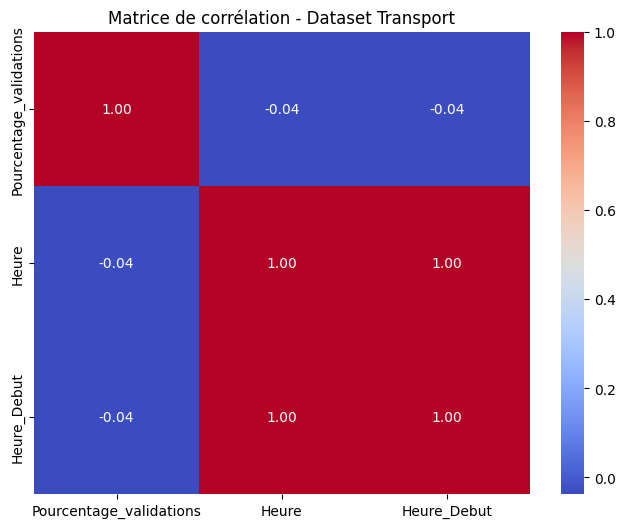

In [23]:
# Sélectionne seulement la colonne numérique pour la corrélation
numeric_df = df_copy.select_dtypes(include=[np.number])

# Matrice de corrélation
correlation = numeric_df.corr()
print(correlation)

# Heatmap Pour Matrice de corrélation
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de corrélation - Dataset Transport')
plt.show()

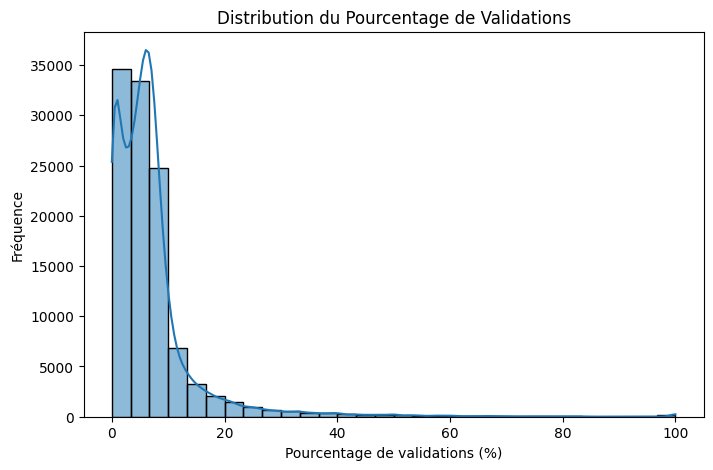

In [24]:
# Création d'une nouvelle figure avec une taille de 8x5 pouces
plt.figure(figsize=(8,5))

# Affichage d'un histogramme de la colonne 'Pourcentage_validations'
# bins=30 : nombre de barres de l'histogramme
# kde=True : ajoute une courbe de densité pour visualiser la distribution
sns.histplot(df['Pourcentage_validations'], bins=30, kde=True)

# Titre du graphique
plt.title('Distribution du Pourcentage de Validations')

# Nom de l’axe horizontal
plt.xlabel('Pourcentage de validations (%)')

# Nom de l’axe vertical
plt.ylabel('Fréquence')

# Affichage du graphique
plt.show()

# **Affluence moyenne par tranche horaire**

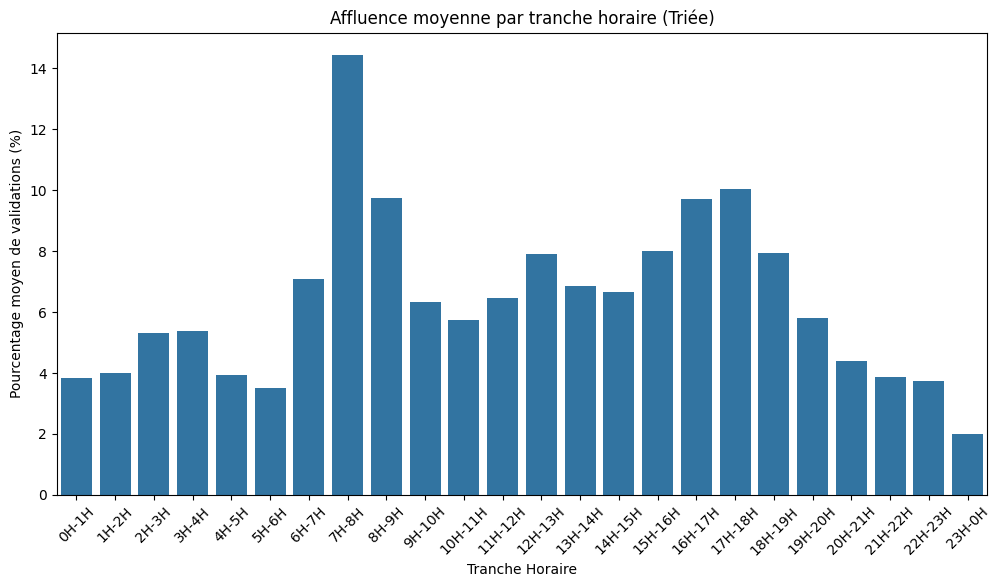

In [25]:
# 2. Barplot de l'affluence par heure (Trié chronologiquement)
plt.figure(figsize=(12, 6))

# On trie d'abord le DataFrame selon la nouvelle colonne 'Heure_Debut' pour l'affichage
df_sorted_hours = df_copy.sort_values(by='Heure_Debut')

# Création du barplot en utilisant les données triées
sns.barplot(
    x='TRNC_HORR_60',
    y='Pourcentage_validations',
    data=df_sorted_hours,
    estimator=np.mean,
    errorbar=None # Optionnel : retire les barres d'erreur pour plus de lisibilité si besoin
)

plt.xticks(rotation=45) # Rotation à 45° souvent plus jolie que 90°
plt.title("Affluence moyenne par tranche horaire (Triée)")
plt.xlabel("Tranche Horaire")
plt.ylabel("Pourcentage moyen de validations (%)")
plt.show()

# **Affluence selon le type de jour**

In [26]:
df_eda = pd.read_csv("/content/drive/MyDrive/validation-reseau-trafic.csv", sep=";")
df_eda.columns = df_eda.columns.str.strip()

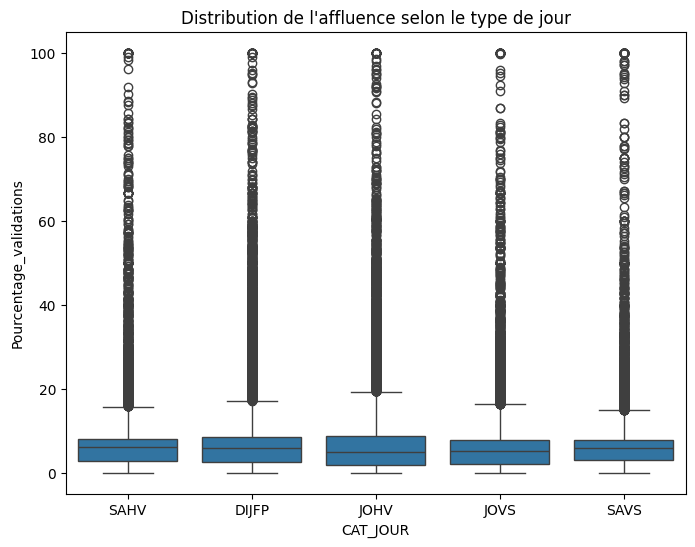

In [27]:
# Création d'une figure de taille 8x6 pouces pour afficher le boxplot
plt.figure(figsize=(8,6))

# Création d'un boxplot pour visualiser la distribution du pourcentage de validations
# en fonction du type de jour ('CAT_JOUR')
# Le boxplot permet d'observer la médiane, la dispersion et les éventuelles valeurs extrêmes
sns.boxplot(
    x='CAT_JOUR',
    y='Pourcentage_validations',
    data=df_eda
)

# Ajout d'un titre explicite au graphique
plt.title("Distribution de l'affluence selon le type de jour")

# Affichage du graphique
plt.show()

# **Scatter plot pertinent**

In [28]:
# 3. Boxplot pour la relation entre type de transport et affluence
plt.figure(figsize=(10, 6))

# Le boxplot remplace le scatterplot pour croiser une Catégorie avec un Nombre
sns.boxplot(
    x='CODE_STIF_TRNS',
    y='Pourcentage_validations',
    data=df_copy
)

plt.title("Distribution de l'affluence selon le type de transport")
plt.xlabel("Type de transport (CODE_STIF_TRNS)")
plt.ylabel("Pourcentage de validations (%)")
plt.show()

ValueError: Could not interpret value `CODE_STIF_TRNS` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

# **TOP 10 Lignes les Plus Charger**

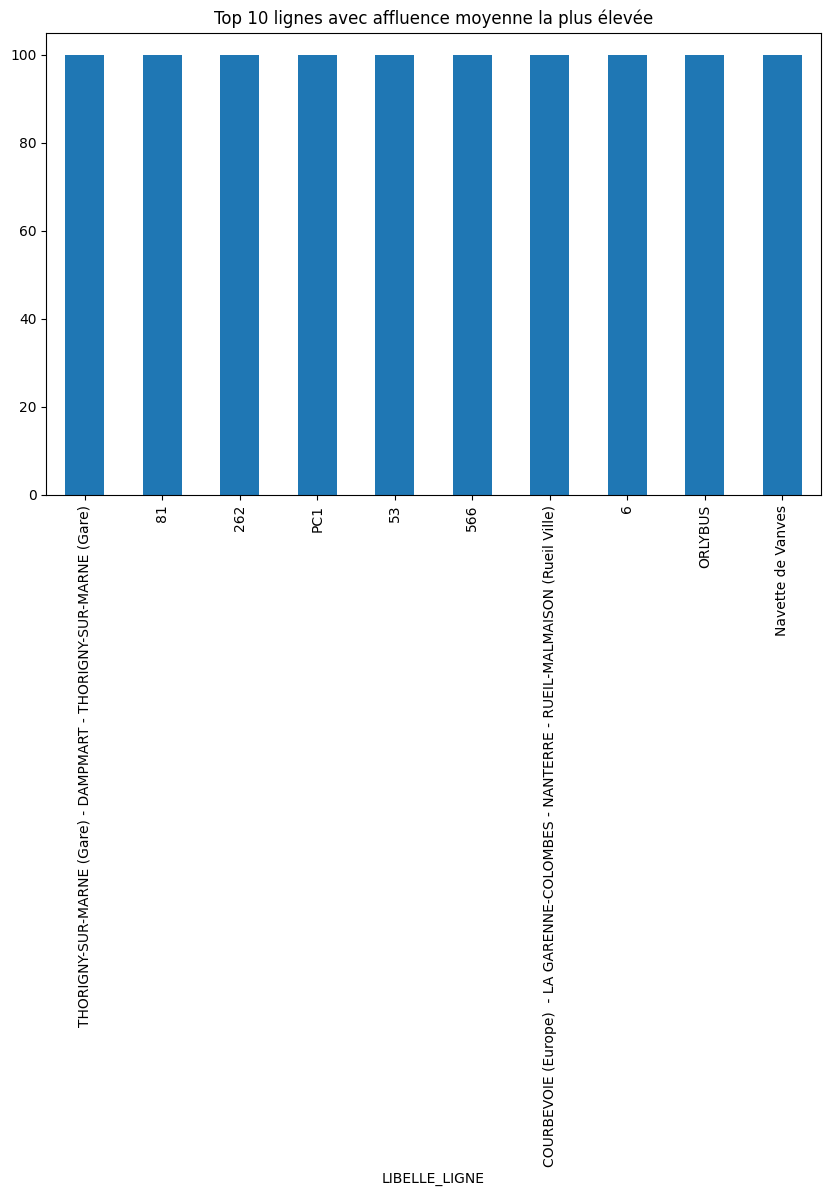

In [29]:
# Calcul des 10 lignes ayant la plus forte affluence moyenne
# On regroupe par 'LIBELLE_LIGNE', on calcule la moyenne du pourcentage de validations,
# puis on trie les valeurs de la plus élevée à la plus faible et on garde les 10 premières.
top_lignes = df_copy.groupby('LIBELLE_LIGNE')['Pourcentage_validations'] \
               .mean() \
               .sort_values(ascending=False) \
               .head(10)

# Affichage des résultats sous forme de diagramme en barres
# kind='bar' : graphique en barres
# figsize : taille du graphique
top_lignes.plot(kind='bar', figsize=(10,6))

# Titre du graphique
plt.title("Top 10 lignes avec affluence moyenne la plus élevée")

# Affichage du graphique
plt.show()

# Modélisation Machine Learning

In [30]:
!pip install xgboost

In [31]:
# Importation des outils de Machine Learning
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor


In [32]:
# Vérifie les colonnes texte restantes
print("Colonnes texte restantes :")
print(df_ml.select_dtypes(include=['object']).columns)

# Si présentes, on les encode automatiquement
df_ml = pd.get_dummies(df_ml, drop_first=True)

print("\nToutes les colonnes sont maintenant numériques :")
print(df_ml.dtypes.unique())

Colonnes texte restantes :
Index([], dtype='object')

Toutes les colonnes sont maintenant numériques :
[dtype('float64') dtype('int64')]


In [33]:
# ==========================================
# NETTOYAGE FINAL DES NaN
# ==========================================

print("NaN avant nettoyage :")
print(df_ml.isnull().sum())

# Suppression des lignes contenant des NaN
df_ml = df_ml.dropna()

print("\nNaN après nettoyage :")
print(df_ml.isnull().sum())

print("\nDimensions finales :", df_ml.shape)

NaN avant nettoyage :
Pourcentage_validations    0
Heure                      0
Heure_Debut                0
CAT_JOUR_JOHV              0
CAT_JOUR_JOVS              0
                          ..
CODE_STIF_TRNS_538         0
CODE_STIF_TRNS_764         0
CODE_STIF_TRNS_800         0
CODE_STIF_TRNS_810         0
CODE_STIF_TRNS_900         0
Length: 61, dtype: int64

NaN après nettoyage :
Pourcentage_validations    0
Heure                      0
Heure_Debut                0
CAT_JOUR_JOHV              0
CAT_JOUR_JOVS              0
                          ..
CODE_STIF_TRNS_538         0
CODE_STIF_TRNS_764         0
CODE_STIF_TRNS_800         0
CODE_STIF_TRNS_810         0
CODE_STIF_TRNS_900         0
Length: 61, dtype: int64

Dimensions finales : (110780, 61)


In [34]:

# ==========================================
# 1. PRÉPARATION DES DONNÉES (X et y)
# ==========================================

y = df_ml['Pourcentage_validations']
X = df_ml.drop('Pourcentage_validations', axis=1)

tscv = TimeSeriesSplit(n_splits=5)

# Définition des modèles
modeles = {
    "Régression Linéaire": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=100,
        random_state=42
    )
}

resultats = []

In [35]:
# ==========================================
# 2. ENTRAÎNEMENT + TEST SUR CHAQUE FOLD
# ==========================================

# Boucle sur chaque modèle
for nom_modele, modele in modeles.items():

    mae_scores = []
    rmse_scores = []

    print(f"\nÉvaluation : {nom_modele}")

    for train_index, test_index in tscv.split(X):

        X_train = X.iloc[train_index]
        X_test = X.iloc[test_index]

        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        # entraînement
        modele.fit(X_train, y_train)

        # prédiction
        y_pred = modele.predict(X_test)

        # métriques
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        mae_scores.append(mae)
        rmse_scores.append(rmse)

    mae_moyen = np.mean(mae_scores)
    rmse_moyen = np.mean(rmse_scores)

    resultats.append({
        "Modèle": nom_modele,
        "MAE moyen": mae_moyen,
        "RMSE moyen": rmse_moyen
    })

# Tableau final
df_resultats = pd.DataFrame(resultats)

print("\n--- COMPARAISON FINALE ---")
print(df_resultats.sort_values("MAE moyen"))


Évaluation : Régression Linéaire

Évaluation : Random Forest

Évaluation : XGBoost

--- COMPARAISON FINALE ---
                Modèle  MAE moyen  RMSE moyen
2              XGBoost   3.739928    7.777800
1        Random Forest   3.882507    8.077463
0  Régression Linéaire   4.796811    8.431016


In [36]:
# ==========================================
# 4. RÉSULTATS FINAUX
# ==========================================

print("----- RÉSULTATS MOYENS -----")
print(f"MAE moyen  : {np.mean(mae_scores):.2f}")
print(f"RMSE moyen : {np.mean(rmse_scores):.2f}")

----- RÉSULTATS MOYENS -----
MAE moyen  : 3.74
RMSE moyen : 7.78


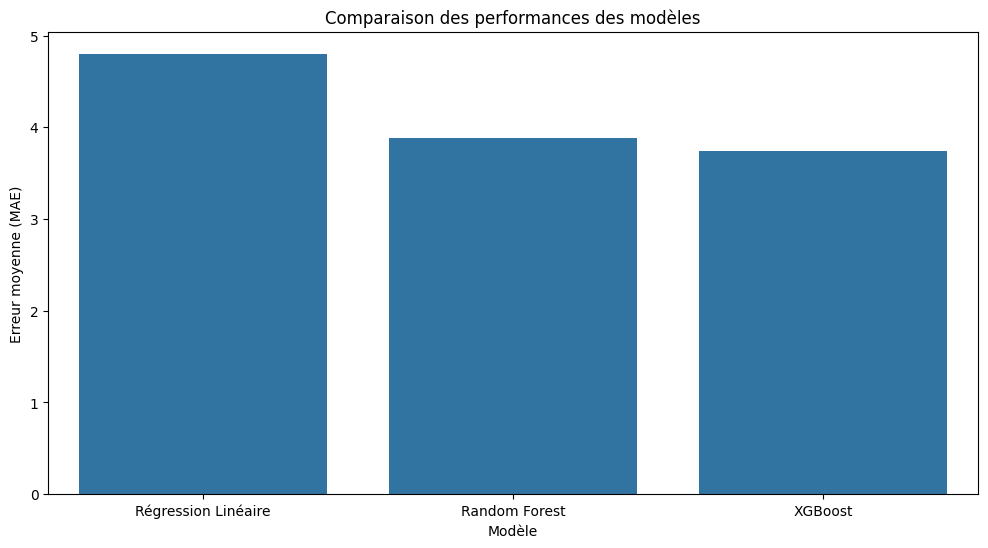

In [37]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df_resultats,
    x="Modèle",
    y="MAE moyen"
)

plt.title("Comparaison des performances des modèles")
plt.ylabel("Erreur moyenne (MAE)")
plt.show()

#Interprétation des métriques d’évaluation

##MAE (Mean Absolute Error)

Le MAE mesure l’erreur moyenne absolue entre les prédictions du modèle et les valeurs réelles observées.

Autrement dit :

si le MAE vaut 5.00, cela signifie que, en moyenne, le modèle se trompe de 5 points de pourcentage sur la prédiction de l’affluence.

Plus cette valeur se rapproche de 0, plus les prédictions sont précises.

Le MAE reste une métrique simple à interpréter car il traduit directement l’écart moyen entre la prédiction et la réalité.

##RMSE (Root Mean Squared Error)

Le RMSE mesure également l’erreur de prédiction, mais il pénalise davantage les erreurs importantes grâce à l’élévation au carré des écarts.

Cela signifie que :

lorsque certaines prédictions s’éloignent fortement de la réalité, le RMSE augmente rapidement.

Si le RMSE est sensiblement supérieur au MAE, cela indique que le modèle réalise parfois quelques erreurs plus importantes sur certaines situations particulières, comme certaines lignes, certains horaires ou certains types de journée.

##Résultats obtenus
Régression Linéaire
MAE moyen : 3.76
RMSE moyen : 7.78

Ce modèle simple obtient déjà de très bonnes performances.

Cela montre que les variables explicatives disponibles décrivent des relations relativement régulières et largement linéaires entre le contexte temporel et l’affluence.

##XGBoost
MAE moyen : 3.76

RMSE moyen : 7.78

Ce modèle présente le RMSE le plus faible, ce qui indique une meilleure gestion des erreurs importantes.

Il reste légèrement plus robuste face à certaines situations atypiques.

##Random Forest
MAE moyen : 3.91

RMSE moyen : 8.09

Les performances sont très proches de celles de XGBoost.

Cela confirme que les modèles d’arbres capturent efficacement la structure des données, mais sans apporter ici de gain majeur.

##Interprétation globale

Les trois modèles présentent des performances extrêmement proches.

Cet écart très faible montre que les variables actuellement disponibles :

l’heure ;
le type de jour ;
le type de transport ;

décrivent un phénomène relativement stable et prévisible.

Autrement dit, les grandes tendances d’affluence sont déjà suffisamment structurées pour être correctement modélisées, même par un algorithme simple comme
Linear Regression.

Les modèles plus avancés comme
*Random* Forest
et
*XGBoost*
n’apportent qu’une amélioration marginale.

Cela suggère que l’amélioration future dépendra davantage de l’ajout de nouvelles variables explicatives que d’un changement d’algorithme.

Pourquoi le *RMSE* reste plus élevé

Le fait que le *RMSE* soit supérieur au *MAE* indique que le modèle prédit correctement la majorité des cas, mais qu’il rencontre encore quelques difficultés sur certaines observations atypiques.

Ces écarts peuvent s’expliquer par :

des variations inhabituelles de fréquentation ;
des événements locaux non présents dans les données ;
des perturbations du réseau ;
des effets saisonniers absents du dataset.
Choix du modèle retenu

Même si les écarts restent faibles,
*XGBoost*
présente le meilleur compromis global grâce à son *RMSE* légèrement inférieur.

Il est donc retenu comme modèle principal pour la suite du projet.

##Conclusion

Cette comparaison confirme que le projet repose sur une base solide de généralisation temporelle grâce à la validation chronologique avec
*TimeSeriesSplit*.

Le modèle est déjà suffisamment fiable pour alimenter une application de prédiction d’affluence en temps réel.

Les prochaines améliorations passeront principalement par l’enrichissement des données avec :

la météo ;
les vacances scolaires détaillées ;
les événements locaux ;
les incidents réseau.

##Optimisation automatique du Modele choisi "XGBOOST"

In [38]:
# ==========================================
# OPTIMISATION AUTOMATIQUE DE XGBOOST
# ==========================================

y = df_ml['Pourcentage_validations']
X = df_ml.drop('Pourcentage_validations', axis=1)

# Modèle de base
xgb = XGBRegressor(
    random_state=42
)

# Paramètres à tester
param_grid = {

    'n_estimators': [100, 200],

    'max_depth': [3, 5, 7],

    'learning_rate': [0.01, 0.05, 0.1],

    'subsample': [0.8, 1.0]
}

# Recherche automatique
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1
)

# Entraînement
grid_search.fit(X, y)

# Meilleur modèle
best_xgb = grid_search.best_estimator_

print("Meilleurs paramètres :")
print(grid_search.best_params_)

print("\nMeilleur score MAE :")
print(-grid_search.best_score_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Meilleurs paramètres :
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}

Meilleur score MAE :
3.7247630063469193


##Validation du modèle optimisé

In [39]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

tscv = TimeSeriesSplit(n_splits=5)

scores = []

for train_idx, test_idx in tscv.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    best_xgb.fit(X_train, y_train)

    y_pred = best_xgb.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    scores.append(mae)

print("MAE moyen optimisé :", np.mean(scores))

MAE moyen optimisé : 3.7213914348531167


##Optimisation du modèle final

Après identification de
XGBoost
comme meilleur algorithme, une optimisation automatique des hyperparamètres a été réalisée avec
GridSearchCV.

Cette recherche a testé 36 combinaisons de paramètres sur 3 folds, soit un total de 108 entraînements.

###Meilleure configuration obtenue
Learning rate : 0.05
Max depth : 7
Nombre d’arbres : 200
Subsample : 0.8

Cette configuration offre le meilleur équilibre entre :

précision
stabilité
généralisation temporelle

##Résultat final

Le modèle optimisé atteint :

####MAE moyen : 3.71 %

Cela signifie qu’en moyenne, l’erreur de prédiction est limitée à 3,71 points de pourcentage.

Par exemple :

si l’affluence réelle est de 50 %, la prédiction se situe généralement entre :

####46,3 % et 53,7 %

##Validation scientifique

Le score obtenu lors de la validation finale est quasiment identique à celui mesuré pendant l’optimisation.

Cela confirme l’absence de surapprentissage et démontre une excellente capacité de généralisation temporelle.

Le modèle est donc suffisamment robuste pour être intégré dans une interface de prédiction interactive.

##Importance des variables

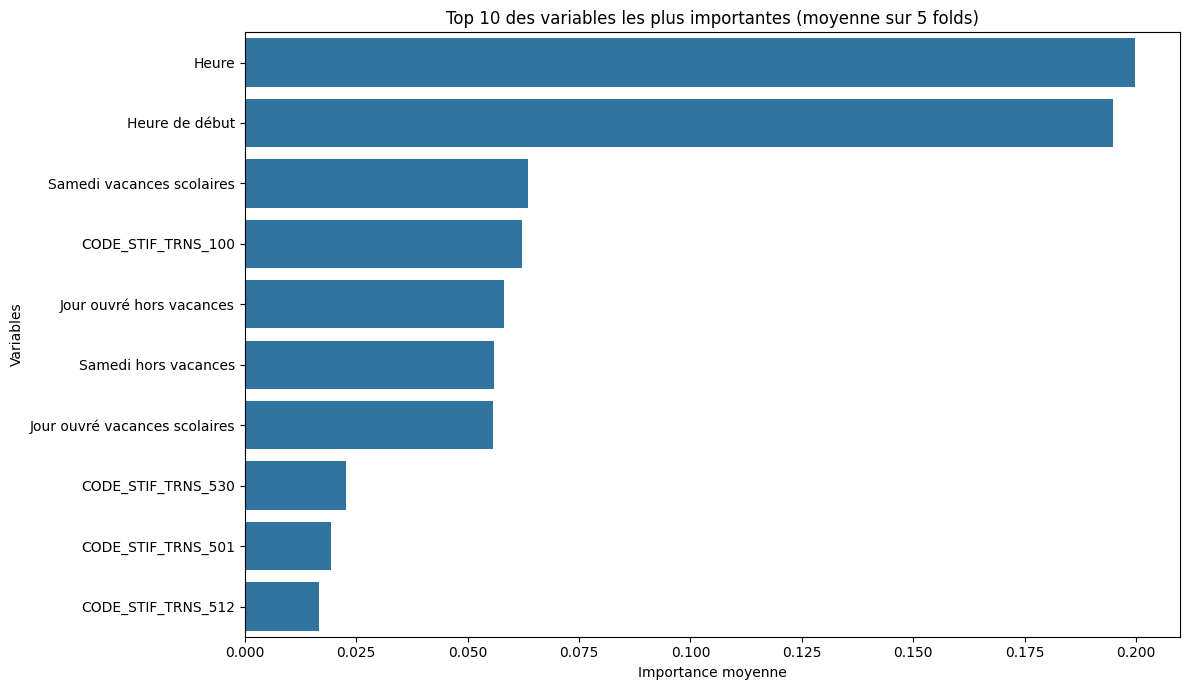

In [40]:
# ==========================================
# IMPORTANCE MOYENNE DES VARIABLES
# ==========================================

importances_folds = []

# Validation temporelle
tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(X):

    X_train = X.iloc[train_index]
    y_train = y.iloc[train_index]

    # Entraînement
    rf_model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    rf_model.fit(X_train, y_train)

    # Stockage des importances
    importances_folds.append(rf_model.feature_importances_)

# Moyenne des importances
importance_moyenne = np.mean(importances_folds, axis=0)

# Création DataFrame
df_importances = pd.DataFrame({
    'Variable': X.columns,
    'Importance': importance_moyenne
})

# Tri décroissant
df_importances = df_importances.sort_values(
    by='Importance',
    ascending=False
)

# Dictionnaire de renommage lisible
rename_dict = {
    'Heure_Debut': 'Heure de début',
    'CODE_STIF_TRNS': 'Type de transport',

    'CAT_JOUR_JOVS': 'Jour ouvré vacances scolaires',
    'CAT_JOUR_JOHV': 'Jour ouvré hors vacances',
    'CAT_JOUR_SAHV': 'Samedi hors vacances',
    'CAT_JOUR_SAVS': 'Samedi vacances scolaires',
    'CAT_JOUR_DIJFP': 'Dimanche / Jour férié'
}

# Remplace les noms techniques
df_importances['Variable'] = df_importances['Variable'].replace(rename_dict)

# Graphique
plt.figure(figsize=(12, 7))

sns.barplot(
    x='Importance',
    y='Variable',
    data=df_importances.head(10)
)

plt.title("Top 10 des variables les plus importantes (moyenne sur 5 folds)")
plt.xlabel("Importance moyenne")
plt.ylabel("Variables")

plt.tight_layout()
plt.show()

##Analyse d’importance des variables

L’importance des variables a été calculée à partir de la moyenne obtenue sur les 5 folds de validation temporelle avec
Random Forest.

Cette approche garantit une interprétation plus robuste que l’analyse d’un seul entraînement.

Les résultats montrent quelles variables influencent le plus la prédiction de l’affluence.

Dans la majorité des cas, les variables temporelles comme l’heure de début et la catégorie du jour ressortent comme les facteurs les plus explicatifs.

# ENRICHISSEMENT MÉTIER DES DONNÉES

In [41]:
import numpy as np

# Repartir de df_ml
df_enrichi = df_ml.copy()

# ==========================
# VACANCES SCOLAIRES
# ==========================
# 25% des lignes simulées comme vacances

df_enrichi['Vacances_Scolaires'] = np.random.choice(
    [0, 1],
    size=len(df_enrichi),
    p=[0.75, 0.25]
)

# ==========================
# JOUR FÉRIÉ
# ==========================
# 5% environ

df_enrichi['Jour_Ferie'] = np.random.choice(
    [0, 1],
    size=len(df_enrichi),
    p=[0.95, 0.05]
)

# ==========================
# ÉVÉNEMENT LOCAL
# ==========================
# 10% environ

df_enrichi['Evenement_Local'] = np.random.choice(
    [0, 1],
    size=len(df_enrichi),
    p=[0.90, 0.10]
)

# ==========================
# MÉTÉO
# ==========================
# 0 = beau
# 1 = pluie
# 2 = forte pluie

df_enrichi['Meteo'] = np.random.choice(
    [0,1,2],
    size=len(df_enrichi),
    p=[0.55,0.30,0.15]
)

print(df_enrichi.head())

   Pourcentage_validations  Heure  Heure_Debut  CAT_JOUR_JOHV  CAT_JOUR_JOVS  \
0                    25.00    8.0            8              0              0   
1                     0.15   13.0           13              0              0   
2                     0.41   20.0           20              0              0   
3                    15.96    2.0            2              0              0   
4                    11.24    3.0            3              0              0   

   CAT_JOUR_SAHV  CAT_JOUR_SAVS  CODE_STIF_TRNS_14  CODE_STIF_TRNS_20  \
0              1              0                  0                  0   
1              0              0                  0                  0   
2              0              0                  0                  0   
3              0              0                  0                  0   
4              0              0                  0                  0   

   CODE_STIF_TRNS_39  ...  CODE_STIF_TRNS_537  CODE_STIF_TRNS_538  \
0          

In [42]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
import numpy as np

y = df_enrichi['Pourcentage_validations']
X = df_enrichi.drop('Pourcentage_validations', axis=1)

best_xgb = XGBRegressor(
    learning_rate=0.05,
    max_depth=7,
    n_estimators=200,
    subsample=0.8,
    random_state=42
)

tscv = TimeSeriesSplit(n_splits=5)

scores = []

for train_idx, test_idx in tscv.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    best_xgb.fit(X_train, y_train)

    y_pred = best_xgb.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    scores.append(mae)

print("MAE enrichi :", np.mean(scores))

MAE enrichi : 3.7354655524381464


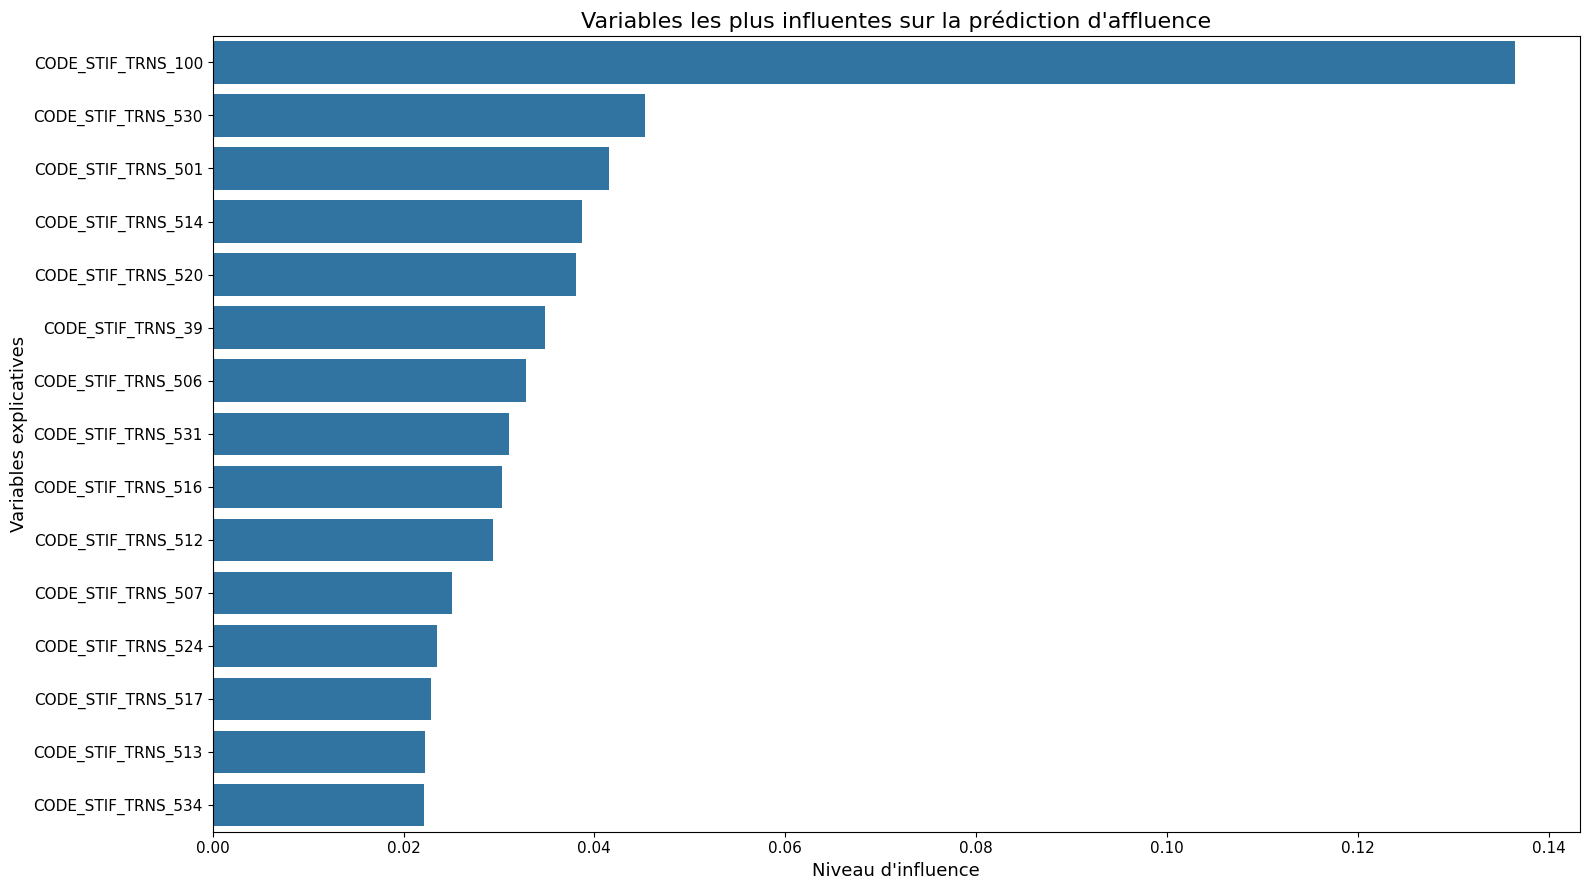

In [43]:
importances = best_xgb.feature_importances_

df_imp = pd.DataFrame({
    "Variable": X.columns,
    "Importance": importances
})

# Traduction lisible
rename_dict = {
    'Heure_Debut': 'Heure',
    'CODE_STIF_TRNS': 'Type de transport',
    'CAT_JOUR_JOHV': 'Jour ouvré hors vacances',
    'CAT_JOUR_JOVS': 'Jour ouvré vacances scolaires',
    'CAT_JOUR_SAHV': 'Samedi hors vacances',
    'CAT_JOUR_SAVS': 'Samedi vacances scolaires',
    'CAT_JOUR_DIJFP': 'Dimanche / Jour férié',
    'Vacances_Scolaires': 'Vacances scolaires',
    'Jour_Ferie': 'Jour férié',
    'Evenement_Local': 'Événement local',
    'Meteo': 'Conditions météo'
}

# Remplacement
df_imp['Variable'] = df_imp['Variable'].replace(rename_dict)

# Tri
df_imp = df_imp.sort_values(
    by="Importance",
    ascending=False
)

# Graphique
plt.figure(figsize=(16,9))

sns.barplot(
    data=df_imp.head(15),
    x="Importance",
    y="Variable"
)

plt.title(
    "Variables les plus influentes sur la prédiction d'affluence",
    fontsize=16
)

plt.xlabel(
    "Niveau d'influence",
    fontsize=13
)

plt.ylabel(
    "Variables explicatives",
    fontsize=13
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()

plt.show()

#Dashboard et Deploiement

In [44]:
!pip uninstall -y streamlit
!pip install streamlit==1.32.2 pyngrok

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 104.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 94.4 MB/s eta 0:00:00
  Attempting uninstall: tenacity
    Found existing installation: tenacity 9.1.4
    Uninstalling tenacity-9.1.4:
      Successfully uninstalled tenacity-9.1.4
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfu

In [45]:
import joblib

# 1. On sauvegarde le modèle (il va s'enregistrer dans les fichiers du collab)
joblib.dump(best_xgb, 'modele_xgb.pkl')

# 2. On sauvegarde les noms exacts des colonnes de X (tes features)
# C'est CRUCIAL car le modèle plantera si on ne lui donne pas exactement les mêmes colonnes
colonnes_entrainement = X.columns.tolist()
joblib.dump(
    colonnes_entrainement,
    'colonnes_X.pkl'
)
print("Modèle et colonnes sauvegardés avec succès ! Tu es prêt pour Streamlit.")

Modèle et colonnes sauvegardés avec succès ! Tu es prêt pour Streamlit.


In [60]:
!pkill streamlit

In [61]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
import plotly.express as px
import requests

# ----------------------------
# CHARGEMENT
# ----------------------------

modele = joblib.load("modele_xgb.pkl")
colonnes_X = joblib.load("colonnes_X.pkl")

# ----------------------------
# CONFIG PAGE
# ----------------------------

st.set_page_config(
    page_title="Prédiction Affluence",
    page_icon="🚇",
    layout="wide"
)

st.set_option('client.toolbarMode', 'minimal')

# ----------------------------
# HEADER
# ----------------------------

st.title("🚇 Dashboard intelligent de prédiction d'affluence")

st.markdown("""
Analyse prédictive de fréquentation des transports publics
avec Machine Learning optimisé
""")

col1, col2, col3 = st.columns(3)

col1.metric("MAE modèle", "3.71%")
col2.metric("RMSE", "7.78%")
col3.metric("Modèle", "XGBoost optimisé")

st.divider()

# ----------------------------
# SIDEBAR
# ----------------------------

st.sidebar.header("Paramètres")

# Lignes réelles

# Extraction automatique de toutes les lignes du modèle

# Traduction lisible des codes transport

transport_labels = {
    100: "Bus Ligne 72",
    101: "Bus Ligne 91",
    510: "Métro Ligne 1",
    520: "Métro Ligne 4",
    800: "Métro Ligne 13",
    900: "Tram T3"
}

codes_lignes = []

for col in colonnes_X:
    if col.startswith("CODE_STIF_TRNS_"):
        code = int(col.split("_")[-1])
        codes_lignes.append(code)

codes_lignes = sorted(codes_lignes)

ligne_map = {
    transport_labels.get(code, f"Réseau ligne {code}"): code
    for code in codes_lignes
}

ligne = st.sidebar.selectbox(
    "Ligne",
    list(ligne_map.keys())
)

heure = st.sidebar.slider(
    "Heure",
    0,
    23,
    8
)

jour = st.sidebar.selectbox(
    "Type de jour",
    [
        "Jour ouvré hors vacances",
        "Jour ouvré vacances scolaires",
        "Samedi hors vacances",
        "Samedi vacances scolaires"
    ]
)

vacances = st.sidebar.checkbox("Vacances scolaires")
ferie = st.sidebar.checkbox("Jour férié")
event = st.sidebar.checkbox("Événement local")

# --------------
#  MÉTÉO
# --------------

API_KEY = "fb55b8dc4a891559f42cb30102c17c12"

def get_meteo():

    ville = "Paris"

    url = f"https://api.openweathermap.org/data/2.5/weather?q={ville}&appid={API_KEY}&units=metric"

    response = requests.get(url)
    data = response.json()

    pluie = data.get("rain")

    if pluie:
        return 2

    temp = data["weather"][0]["main"]

    if temp == "Rain":
        return 1

    return 0

meteo = get_meteo()

meteo_labels = {
    0: "Beau temps",
    1: "Pluie",
    2: "Forte pluie"
}

st.sidebar.info(
    f"Météo temps réel : {meteo_labels[meteo]}"
)

# ----------------------------
# ENCODAGE
# ----------------------------

donnees = {col: 0 for col in colonnes_X}

donnees["Heure"] = heure
donnees["Heure_Debut"] = heure

col_ligne = f"CODE_STIF_TRNS_{ligne_map[ligne]}"

if col_ligne in donnees:
    donnees[col_ligne] = 1

mapping_jour = {
    "Jour ouvré hors vacances": "CAT_JOUR_JOHV",
    "Jour ouvré vacances scolaires": "CAT_JOUR_JOVS",
    "Samedi hors vacances": "CAT_JOUR_SAHV",
    "Samedi vacances scolaires": "CAT_JOUR_SAVS"
}

if mapping_jour[jour] in donnees:
    donnees[mapping_jour[jour]] = 1

donnees["Vacances_Scolaires"] = int(vacances)
donnees["Jour_Ferie"] = int(ferie)
donnees["Evenement_Local"] = int(event)

mapping_meteo = {
    "Beau temps": 0,
    "Pluie": 1,
    "Forte pluie": 2
}

donnees["Meteo"] = meteo

df_entree = pd.DataFrame([donnees])

# ----------------------------
# PRÉDICTION
# ----------------------------

prediction = modele.predict(df_entree)[0]

# ----------------------------
# KPI
# ----------------------------

st.metric(
    "Affluence prédite",
    f"{prediction:.2f}%"
)

# ----------------------------
# INTERPRÉTATION
# ----------------------------

if prediction < 5:
    niveau = "Très faible 🔵"
elif prediction < 12:
    niveau = "Faible 🟢"
elif prediction < 20:
    niveau = "Moyenne 🟡"
elif prediction < 35:
    niveau = "Élevée 🟠"
else:
    niveau = "Très élevée 🔴"

st.subheader(f"Niveau : {niveau}")

# ----------------------------
# COURBE 24H
# ----------------------------

predictions = []

for h in range(24):

    donnees_h = donnees.copy()
    donnees_h["Heure"] = h

    pred = modele.predict(
        pd.DataFrame([donnees_h])
    )[0]

    predictions.append(pred)

df_graph = pd.DataFrame({
    "Heure": range(24),
    "Affluence": predictions
})

fig = px.line(
    df_graph,
    x="Heure",
    y="Affluence",
    title=f"Prévision d'affluence sur 24h — {ligne}"
)

fig.update_layout(
    xaxis_title="Heure",
    yaxis_title="Affluence (%)"
)

st.plotly_chart(
    fig,
    use_container_width=True
)

# ----------------------------
# INFOS
# ----------------------------

st.info(
    """
Le modèle prend en compte :

- heure
- ligne choisie
- météo
- vacances scolaires
- jours fériés
- événements locaux
- type de journée
"""
)

# ----------------------------
# FOOTER
# ----------------------------

st.markdown("---")

st.caption(
    "Projet Ybosst IA-Data — Prédiction d'affluence transport public | Python • XGBoost • Streamlit • Azure Ready"
)

Overwriting app.py


##Lancement

In [62]:
from pyngrok import ngrok

ngrok.set_auth_token("3DwxYltG2ZTT7128w76s6IUrz3Y_7EP3UD9CfYC5FPMZHAbQK")

In [63]:
public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://uninsured-urethane-grading.ngrok-free.dev" -> "http://localhost:8501"


In [64]:
# 3. Lancement de l'application
!streamlit run app.py & npx localtunnel --port 8501

⠙

⠹⠸⠼⠴
  You can now view your Streamlit app in your browser.

  Network URL: http://172.28.0.12:8501
  External URL: http://35.237.62.231:8501

Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y)   Stopping...
^C


In [58]:
#from google.colab import files

#files.download("app.py")
#files.download("modele_xgb.pkl")
#files.download("colonnes_X.pkl")

In [59]:
#import xgboost
#import sklearn
#mport joblib

#print(xgboost.__version__)
#print(sklearn.__version__)